---
---
---

# Models

---
---
---

<br>

> | **_Language:_** python@3.12.10 |
> | - |

<br>

> | **_Source:_** `notebook/models.ipynb` |
> | - |

<br>

> | **_Configurations:_** `lib/config` |
> | - |

<br>

> | **_Libraries:_** `lib/utils` |
> | - |

<br>

---
---
---

## Dependencies

### Packages

In [1]:
from google.cloud import bigquery
from loguru import logger
from matplotlib import pyplot as plt
from pathlib import Path
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import joblib
import numpy as np
import pandas as pd
import sys
import warnings

ROOT_PATH = Path.cwd().resolve()
if ROOT_PATH.name in ["notebook"]:
    ROOT_PATH = ROOT_PATH.parent
if str(ROOT_PATH) not in sys.path:
    sys.path.insert(0, str(ROOT_PATH))

from lib import config as the_config
from lib import utils as the_utils
from lib import ml_metrics as metrics_lib
from lib.automl import AutoMLClassifier, AutoMLRegressor

# -------------------------

# Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format", "{:.3f}".format)
warnings.filterwarnings("ignore")

### Constants

In [2]:
# GCP
BQ_CLIENT = bigquery.Client(project=the_config.GCP_PROJECT)

### Paths

In [3]:
for path in the_config.PATHS:
    the_utils.ensure_path(path)

## DataFrame

In [4]:
query = f"""
	SELECT * FROM `{the_config.BQ_TABLE}`
	ORDER BY TIMESTAMP(
		DATETIME(year, month, day, hour, minute, 0)
	)
"""
df = BQ_CLIENT.query(query).to_dataframe()
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128611 entries, 0 to 128610
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 128611 non-null  dbdate 
 1   year                 128611 non-null  Int64  
 2   month                128611 non-null  Int64  
 3   day                  128611 non-null  Int64  
 4   hour                 128611 non-null  Int64  
 5   minute               128611 non-null  Int64  
 6   quarter              128611 non-null  Int64  
 7   week_of_year         128611 non-null  Int64  
 8   day_of_year          128611 non-null  Int64  
 9   day_of_week          128611 non-null  Int64  
 10  station              128611 non-null  object 
 11  city                 128611 non-null  object 
 12  province             128611 non-null  object 
 13  latitude             128611 non-null  float64
 14  longitude            128611 non-null  float64
 15  temperature_c    

None

## Feature Engineering

In [5]:
clf_df = df.iloc[-the_config.ML_HYPER_SPACE["sampling"]:]
clf_df, target_clf = the_utils.feature_engineering_clf(
	clf_df, inference=False
)
clf_df = clf_df.assign(
	timestamp=lambda x: pd.to_datetime(
		x[["year", "month", "day", "hour", "minute"]]
	)
)
logger.debug(f"[LIST] Targets ({len(target_clf)}): {target_clf}")

2026-08-21 12:06:28.973 | DEBUG    | __main__:<module>:10 - [LIST] Targets (1): ['rain_flag']


In [6]:
reg_df = df.iloc[-the_config.ML_HYPER_SPACE["sampling"]:]
reg_df, targets_reg = the_utils.feature_engineering_reg(
	reg_df, inference=False
)
reg_df = reg_df.assign(
	timestamp=lambda x: pd.to_datetime(
		x[["year", "month", "day", "hour", "minute"]]
	)
)
logger.debug(f"[LIST] Targets ({len(targets_reg)}): {targets_reg}")

2026-08-21 12:06:29.422 | DEBUG    | __main__:<module>:10 - [LIST] Targets (28): ['temperature_c_lead_30', 'humidity_pct_lead_30', 'dew_point_c_lead_30', 'pressure_hpa_lead_30', 'wind_speed_kmh_lead_30', 'wind_x_lead_30', 'wind_y_lead_30', 'temperature_c_lead_60', 'humidity_pct_lead_60', 'dew_point_c_lead_60', 'pressure_hpa_lead_60', 'wind_speed_kmh_lead_60', 'wind_x_lead_60', 'wind_y_lead_60', 'temperature_c_lead_90', 'humidity_pct_lead_90', 'dew_point_c_lead_90', 'pressure_hpa_lead_90', 'wind_speed_kmh_lead_90', 'wind_x_lead_90', 'wind_y_lead_90', 'temperature_c_lead_120', 'humidity_pct_lead_120', 'dew_point_c_lead_120', 'pressure_hpa_lead_120', 'wind_speed_kmh_lead_120', 'wind_x_lead_120', 'wind_y_lead_120']


## Training

### Train-Test Split

In [7]:
# Feature Selection -- Classification
to_drop = [
	*the_config.CLASSIFICATION["to_drop"],
	"timestamp"
]
to_drop += [c for c in clf_df.columns if c.lower().startswith("conf_")]
X_clf = clf_df.drop(columns=to_drop)
y_clf = clf_df[the_config.CLASSIFICATION["targets"][0]]

# Train-Test Split -- Classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
	X_clf, y_clf,
    test_size=the_config.CLASSIFICATION["test_size"],
    shuffle=the_config.CLASSIFICATION["shuffle"],
    random_state=the_config.CLASSIFICATION["seed"]
)

logger.debug(f"{'[LIST]':<8}{'[CLF]':<6}{'Features:':<10}{X_train_clf.columns.tolist()}")
logger.debug(f"{'[LIST]':<8}{'[CLF]':<6}{'Labels:':<10}{y_train_clf.name}")
logger.debug(f"{'[TRAIN]':<8}{'[CLF]':<6}{'Shape:':<10}{y_train_clf.shape}")
logger.debug(f"{'[TEST]':<8}{'[CLF]':<6}{'Shape:':<10}{y_test_clf.shape}")

2026-08-21 12:06:29.452 | DEBUG    | __main__:<module>:18 - [LIST]  [CLF] Features: ['latitude', 'longitude', 'temperature_c', 'humidity_pct', 'dew_point_c', 'wind_speed_kmh', 'pressure_hpa', 'rain_flag']
2026-08-21 12:06:29.452 | DEBUG    | __main__:<module>:19 - [LIST]  [CLF] Labels:   rain_flag
2026-08-21 12:06:29.452 | DEBUG    | __main__:<module>:20 - [TRAIN] [CLF] Shape:    (30643,)
2026-08-21 12:06:29.452 | DEBUG    | __main__:<module>:21 - [TEST]  [CLF] Shape:    (7661,)


In [8]:
# Feature Selection -- Regression
to_drop = [
	*the_config.REGRESSION["to_drop"],
    *targets_reg,
	"timestamp"
]
to_drop += [c for c in reg_df.columns if c.lower().startswith("conf_")]
X_reg = reg_df.drop(columns=to_drop)
y_reg = reg_df[targets_reg]

# Train-Test Split -- Regression
X_train_reg = X_reg.iloc[:-the_config.INF_ROWS]
y_train_reg = y_reg.iloc[:-the_config.INF_ROWS]
X_test_reg = X_reg.iloc[-the_config.INF_ROWS:]
y_test_reg = y_reg.iloc[-the_config.INF_ROWS:]

logger.debug(f"{'[LIST]':<8}{'[REG]':<6}{'Features:':<10}{X_train_reg.columns.tolist()}")
logger.debug(f"{'[LIST]':<8}{'[REG]':<6}{'Labels:':<10}{y_train_reg.columns.tolist()}")
logger.debug(f"{'[TRAIN]':<8}{'[REG]':<6}{'Shape:':<10}{y_train_reg.shape}")
logger.debug(f"{'[TEST]':<8}{'[REG]':<6}{'Shape:':<10}{y_test_reg.shape}")

2026-08-21 12:06:29.465 | DEBUG    | __main__:<module>:17 - [LIST]  [REG] Features: ['year', 'month', 'day', 'hour', 'minute', 'quarter', 'week_of_year', 'day_of_year', 'day_of_week', 'latitude', 'longitude', 'temperature_c', 'humidity_pct', 'dew_point_c', 'wind_speed_kmh', 'pressure_hpa', 'wind_x', 'wind_y', 'temperature_c_lag_1', 'temperature_c_lag_2', 'temperature_c_lag_3', 'temperature_c_lag_6', 'temperature_c_lag_12', 'temperature_c_lag_18', 'temperature_c_lag_24', 'humidity_pct_lag_1', 'humidity_pct_lag_2', 'humidity_pct_lag_3', 'humidity_pct_lag_6', 'humidity_pct_lag_12', 'humidity_pct_lag_18', 'humidity_pct_lag_24', 'dew_point_c_lag_1', 'dew_point_c_lag_2', 'dew_point_c_lag_3', 'dew_point_c_lag_6', 'dew_point_c_lag_12', 'dew_point_c_lag_18', 'dew_point_c_lag_24', 'pressure_hpa_lag_1', 'pressure_hpa_lag_2', 'pressure_hpa_lag_3', 'pressure_hpa_lag_6', 'pressure_hpa_lag_12', 'pressure_hpa_lag_18', 'pressure_hpa_lag_24', 'wind_speed_kmh_lag_1', 'wind_speed_kmh_lag_2', 'wind_speed_k

### Models

In [9]:
# Dummy Classifier
dummy_clf = DummyClassifier(strategy="prior")
dummy_clf.fit(X_train_clf, y_train_clf)
display(dummy_clf)

# Dummy Regressor
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train_reg, y_train_reg)
display(dummy_reg)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.69,0.31]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](8,)","['latitude','longitude','temperature_c',...,'wind_speed_kmh', 'pressure_hpa','rain_flag']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,8
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 28)","[[24.91,66.53,17.71,..., 5.16, 0.79, 0.03]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](151,)","['year','month','day',...,'wind_y_std_24','wind_y_min_24','wind_y_max_24']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,151
n_outputs_ n_outputs_: intNumber of outputs.,int,28


In [10]:
# AutoML Classifier -- Random Forest
model_path = the_config.MODELS_PATH / "random_forest_classifier.joblib"
if model_path.exists():
    rf_clf = joblib.load(model_path)

else:
	rf_clf = AutoMLClassifier(
		**the_config.ML_HYPER_SPACE["automl_clf"],
		estimator_list=["rf"],
		seed=the_config.CLASSIFICATION["seed"]
	)
	rf_clf.fit(X_train_clf, y_train_clf)
display(rf_clf)

# AutoML Regressor -- Random Forest
model_path = the_config.MODELS_PATH / "random_forest_regressor.joblib"
if model_path.exists():
    rf_reg = joblib.load(model_path)

else:
	rf_reg = AutoMLRegressor(
		**the_config.ML_HYPER_SPACE["automl_reg"],
		estimator_list=["rf"],
		seed=the_config.REGRESSION["seed"]
	)
	rf_reg.fit(X_train_reg, y_train_reg)
display(rf_reg)

In [11]:
# AutoML Classifier -- LGBM
model_path = the_config.MODELS_PATH / "lgbm_classifier.joblib"
if model_path.exists():
    lgbm_clf = joblib.load(model_path)

else:
	lgbm_clf = AutoMLClassifier(
		**the_config.ML_HYPER_SPACE["automl_clf"],
		estimator_list=["lgbm"],
		seed=the_config.CLASSIFICATION["seed"]
	)
	lgbm_clf.fit(X_train_clf, y_train_clf)
display(lgbm_clf)

# AutoML Regressor -- LGBM
model_path = the_config.MODELS_PATH / "lgbm_regressor.joblib"
if model_path.exists():
    lgbm_reg = joblib.load(model_path)

else:
	lgbm_reg = AutoMLRegressor(
		**the_config.ML_HYPER_SPACE["automl_reg"],
		estimator_list=["lgbm"],
		seed=the_config.REGRESSION["seed"]
	)
	lgbm_reg.fit(X_train_reg, y_train_reg)
display(lgbm_reg)

In [12]:
# AutoML Classifier -- XGBoost
model_path = the_config.MODELS_PATH / "xgboost_classifier.joblib"
if model_path.exists():
    xgb_clf = joblib.load(model_path)

else:
	xgb_clf = AutoMLClassifier(
		**the_config.ML_HYPER_SPACE["automl_clf"],
		estimator_list=["xgboost"],
		seed=the_config.CLASSIFICATION["seed"]
	)
	xgb_clf.fit(X_train_clf, y_train_clf)
display(xgb_clf)

# AutoML Regressor -- XGBoost
model_path = the_config.MODELS_PATH / "xgboost_regressor.joblib"
if model_path.exists():
    xgb_reg = joblib.load(model_path)

else:
	xgb_reg = AutoMLRegressor(
		**the_config.ML_HYPER_SPACE["automl_reg"],
		estimator_list=["xgboost"],
		seed=the_config.REGRESSION["seed"]
	)
	xgb_reg.fit(X_train_reg, y_train_reg)
display(xgb_reg)

In [13]:
# AutoML Classifier
model_path = the_config.MODELS_PATH / "automl_classifier.joblib"
if model_path.exists():
    automl_clf = joblib.load(model_path)

else:
	automl_clf = AutoMLClassifier(
		**the_config.ML_HYPER_SPACE["automl_clf"],
		estimator_list=[
            "rf",
            "lgbm",
            "xgboost"
        ],
		seed=the_config.CLASSIFICATION["seed"]
	)
	automl_clf.fit(X_train_clf, y_train_clf)
display(automl_clf)

# AutoML Regressor
model_path = the_config.MODELS_PATH / "automl_regressor.joblib"
if model_path.exists():
    automl_reg = joblib.load(model_path)

else:
	automl_reg = AutoMLRegressor(
		**the_config.ML_HYPER_SPACE["automl_reg"],
		estimator_list=[
			"rf",
			"lgbm",
			"xgboost"
		],
		seed=the_config.REGRESSION["seed"]
	)
	automl_reg.fit(X_train_reg, y_train_reg)
display(automl_reg)

## Evaluation

In [14]:
models_clf = {
    "Dummy Classifier": { "model": dummy_clf, "metrics": {} },
    "Random Forest Classifier": { "model": rf_clf, "metrics": {} },
    "LGBM Classifier": { "model": lgbm_clf, "metrics": {} },
    "XGBoost Classifier": { "model": xgb_clf, "metrics": {} },
	"AutoML Classifier": { "model": automl_clf, "metrics": {} }
}
for model_name, model_info in models_clf.items():

	logger.debug(f"Model: {model_name}")
	model = model_info["model"]
	model_metrics = model_info["metrics"]

	y_true_train_clf = y_train_clf
	y_true_test_clf = y_test_clf
	y_pred_train_clf = model.predict(X_train_clf)
	y_pred_test_clf = model.predict(X_test_clf)

	model_metrics[the_config.CLASSIFICATION["targets"][0]] = {}
	metrics_lib.compute_metrics_clf(
		model_metrics[the_config.CLASSIFICATION["targets"][0]],
		y_true_train_clf,
		y_pred_train_clf,
		model_classes=[0, 1],
		set="TRAIN"
	)
	metrics_lib.compute_metrics_clf(
		model_metrics[the_config.CLASSIFICATION["targets"][0]],
		y_true_test_clf,
		y_pred_test_clf,
		model_classes=[0, 1],
		set="TEST"
	)

2026-08-21 12:06:31.354 | DEBUG    | __main__:<module>:10 - Model: Dummy Classifier
2026-08-21 12:06:31.412 | DEBUG    | __main__:<module>:10 - Model: Random Forest Classifier
2026-08-21 12:06:31.488 | DEBUG    | __main__:<module>:10 - Model: LGBM Classifier
2026-08-21 12:06:31.522 | DEBUG    | __main__:<module>:10 - Model: XGBoost Classifier
2026-08-21 12:06:31.552 | DEBUG    | __main__:<module>:10 - Model: AutoML Classifier


In [15]:
models_reg = {
	"Dummy Regressor": { "model": dummy_reg, "metrics": {} },
    "Random Forest Regressor": { "model": rf_reg, "metrics": {} },
    "LGBM Regressor": { "model": lgbm_reg, "metrics": {} },
    "XGBoost Regressor": { "model": xgb_reg, "metrics": {} },
	"AutoML Regressor": { "model": automl_reg, "metrics": {} }
}
for model_name, model_info in models_reg.items():

	logger.debug(f"Model: {model_name}")
	model = model_info["model"]
	model_metrics = model_info["metrics"]

	y_true_train_reg = y_train_reg
	y_true_test_reg = y_test_reg
	y_pred_train_reg = pd.DataFrame(
		model.predict(X_train_reg),
		columns=y_train_reg.columns,
		index=y_train_reg.index
	)
	y_pred_test_reg = pd.DataFrame(
		model.predict(X_test_reg),
		columns=y_test_reg.columns,
		index=y_test_reg.index
	)

	for forecast in the_config.FENG_FORECASTS:

		model_metrics[forecast] = {}
		for feature in the_config.REGRESSION["targets"]:

			col = f"{feature}_lead_{forecast}"
			model_metrics[forecast][feature] = {}
			metrics_lib.compute_metrics_reg(
				model_metrics[forecast][feature],
				y_true_train_reg[[col]],
				y_pred_train_reg[[col]],
				set="TRAIN"
			)
			metrics_lib.compute_metrics_reg(
				model_metrics[forecast][feature],
				y_true_test_reg[[col]],
				y_pred_test_reg[[col]],
				set="TEST"
			)

2026-08-21 12:06:31.588 | DEBUG    | __main__:<module>:10 - Model: Dummy Regressor
2026-08-21 12:06:31.673 | DEBUG    | __main__:<module>:10 - Model: Random Forest Regressor
2026-08-21 12:06:33.865 | DEBUG    | __main__:<module>:10 - Model: LGBM Regressor
2026-08-21 12:06:36.787 | DEBUG    | __main__:<module>:10 - Model: XGBoost Regressor
2026-08-21 12:06:39.869 | DEBUG    | __main__:<module>:10 - Model: AutoML Regressor


## Results

count   30643.000
mean        0.310
std         0.463
min         0.000
25%         0.000
50%         0.000
75%         1.000
max         1.000
Name: rain_flag, dtype: float64

,Model,Target,Set,Size,Accuracy,Precision,Recall,F1 Score,Confusion Matrix
0,Dummy Classifier,rain_flag,TRAIN,30643,0.690,0.000,0.000,0.000,"[[21139, 0], [9504, 0]]"
1,Dummy Classifier,rain_flag,TEST,7661,0.692,0.000,0.000,0.000,"[[5302, 0], [2359, 0]]"
2,Random Forest Classifier,rain_flag,TRAIN,30643,0.906,1.000,0.698,0.822,"[[21139, 0], [2871, 6633]]"
3,Random Forest Classifier,rain_flag,TEST,7661,0.910,1.000,0.706,0.828,"[[5302, 0], [693, 1666]]"
4,LGBM Classifier,rain_flag,TRAIN,30643,0.994,1.000,0.982,0.991,"[[21139, 0], [175, 9329]]"
5,LGBM Classifier,rain_flag,TEST,7661,0.993,1.000,0.978,0.989,"[[5302, 0], [53, 2306]]"
6,XGBoost Classifier,rain_flag,TRAIN,30643,0.996,1.000,0.988,0.994,"[[21139, 0], [118, 9386]]"
7,XGBoost Classifier,rain_flag,TEST,7661,0.996,1.000,0.986,0.993,"[[5302, 0], [34, 2325]]"
8,AutoML Classifier,rain_flag,TRAIN,30643,0.994,1.000,0.982,0.991,"[[21139, 0], [175, 9329]]"
9,AutoML Classifier,rain_flag,TEST,7661,0.993,1.000,0.978,0.989,"[[5302, 0], [53, 2306]]"


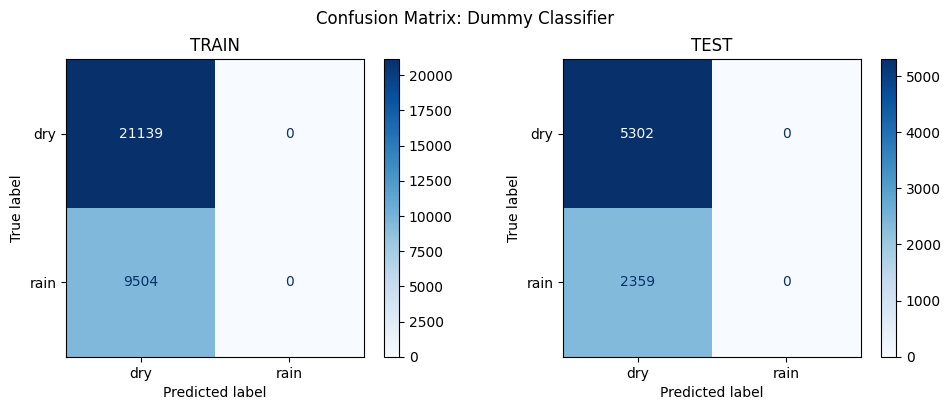

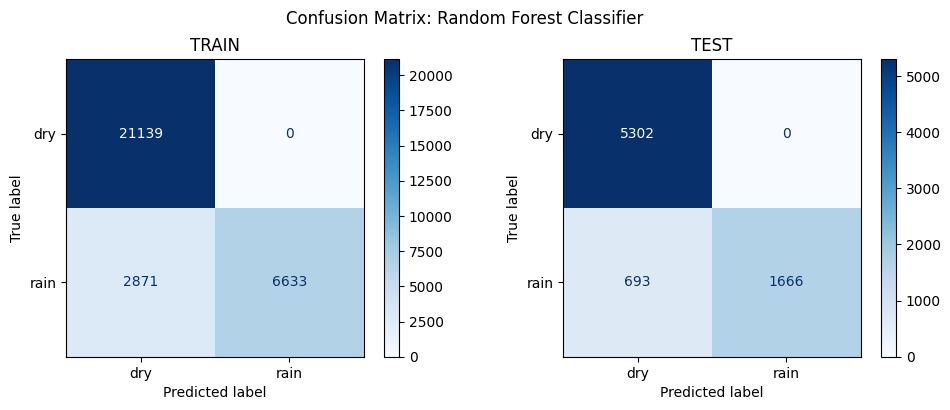

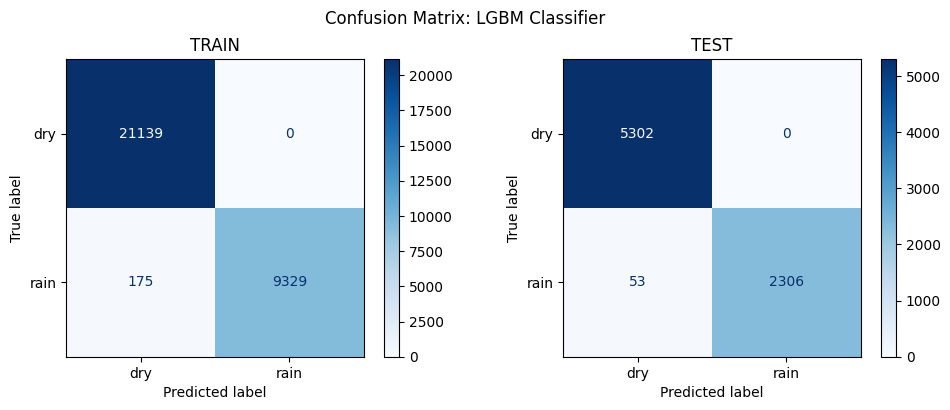

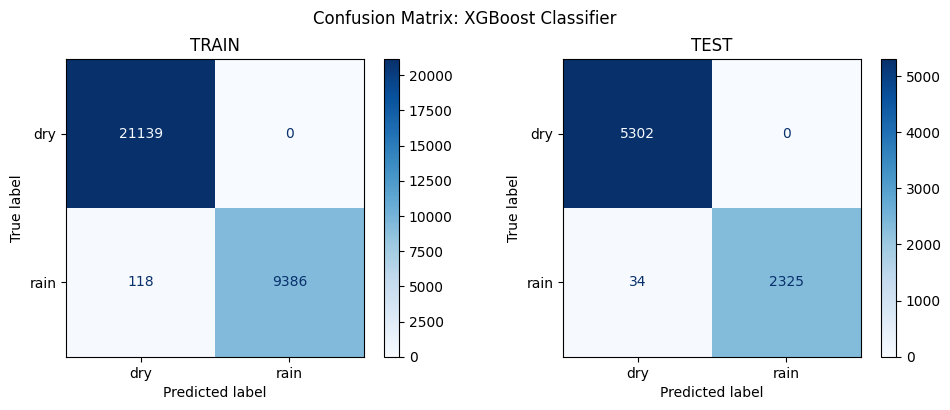

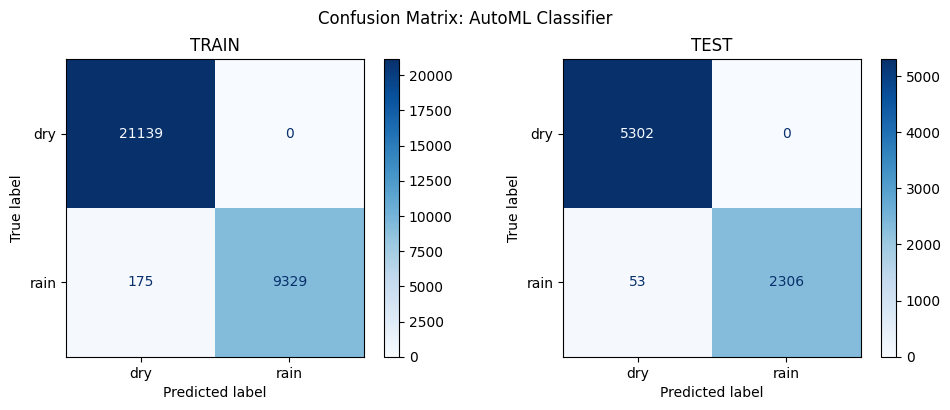

In [16]:
# Metrics -- Classification
rows_clf = []
for model_name, model_info in models_clf.items():

	for target, sets in model_info["metrics"].items():
		for split in ["TRAIN", "TEST"]:

			size, accuracy, precision, recall, f1_score, cm = sets[split]
			rows_clf.append({
				"Model": model_name,
				"Target": target,
				"Set": split,
				"Size": size,
				"Accuracy": accuracy,
				"Precision": precision,
				"Recall": recall,
				"F1 Score": f1_score,
				"Confusion Matrix": cm
			})
metrics_clf_df = (
    pd.DataFrame(rows_clf)
    .reset_index(drop=True)
)

display(y_train_clf.describe())
display(metrics_clf_df)

# Confusion Matrix -- Classification
for model_name in metrics_clf_df["Model"].unique():

    model_results = metrics_clf_df[
        metrics_clf_df["Model"] == model_name
    ]
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, (_, row) in zip(
        axes,
        (
			model_results
			.set_index("Set")
			.loc[["TRAIN", "TEST"]]
			.reset_index()
			.iterrows()
		)
    ):

        cm = np.array(row["Confusion Matrix"])
        cm = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["dry", "rain"]
        )
        cm.plot(
            ax=ax,
            cmap="Blues",
            values_format="d"
        )
        ax.set_title(row["Set"])

    fig.suptitle(f"Confusion Matrix: {model_name}")
    fig.tight_layout()
    fig.savefig(
        the_config.MODELS_PATH /
        f"{model_name.lower().replace(' ', '_')}_cm.png",
        bbox_inches="tight",
        dpi=300
    )
    plt.show()
    plt.close(fig)

In [17]:
# Metrics -- Regression
rows_reg = []
for model_name, model_info in models_reg.items():
    for lead, targets in model_info["metrics"].items():
        for target, sets in targets.items():
            for split in ["TRAIN", "TEST"]:

                size, mae, rmse, r2 = sets[split]
                rows_reg.append({
                    "Model": model_name,
                    "Target": target,
                    "Lead": lead,
                    "Set": split,
                    "Size": size,
                    "MAE": mae,
                    "RMSE": rmse,
                    "R2": r2,
                })                
metrics_reg_df = (
    pd.DataFrame(rows_reg)
    .sort_values(["Target", "Lead"])
    .reset_index(drop=True)
)

display(y_train_reg.describe())
display(metrics_reg_df)

,temperature_c_lead_30,humidity_pct_lead_30,dew_point_c_lead_30,pressure_hpa_lead_30,wind_speed_kmh_lead_30,wind_x_lead_30,wind_y_lead_30,temperature_c_lead_60,humidity_pct_lead_60,dew_point_c_lead_60,pressure_hpa_lead_60,wind_speed_kmh_lead_60,wind_x_lead_60,wind_y_lead_60,temperature_c_lead_90,humidity_pct_lead_90,dew_point_c_lead_90,pressure_hpa_lead_90,wind_speed_kmh_lead_90,wind_x_lead_90,wind_y_lead_90,temperature_c_lead_120,humidity_pct_lead_120,dew_point_c_lead_120,pressure_hpa_lead_120,wind_speed_kmh_lead_120,wind_x_lead_120,wind_y_lead_120
count,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000,35995.000
mean,24.912,66.525,17.707,1011.707,5.188,0.680,0.020,24.857,66.691,17.692,1011.694,5.177,0.713,0.022,24.799,66.867,17.678,1011.682,5.169,0.752,0.025,24.739,67.053,17.664,1011.670,5.159,0.793,0.031
std,4.576,16.088,1.933,2.346,6.689,6.684,5.150,4.585,16.137,1.932,2.344,6.680,6.668,5.142,4.591,16.182,1.931,2.344,6.683,6.663,5.141,4.595,16.223,1.930,2.346,6.688,6.660,5.135
min,14.800,32.000,8.900,965.100,0.000,-35.400,-46.102,14.800,32.000,8.900,965.100,0.000,-35.400,-46.102,14.800,32.000,8.900,965.100,0.000,-35.400,-46.102,14.800,32.000,8.900,965.100,0.000,-35.400,-46.102
25%,21.200,53.000,16.600,1010.000,0.000,-1.131,-0.612,21.100,53.000,16.600,1010.000,0.000,-1.131,-0.612,21.000,53.000,16.600,1010.000,0.000,-1.131,-0.612,20.900,54.000,16.600,1010.000,0.000,-1.131,-0.612
50%,24.700,64.000,17.900,1011.600,3.200,0.000,0.000,24.700,65.000,17.800,1011.600,3.200,0.000,0.000,24.600,65.000,17.800,1011.500,3.200,0.000,0.000,24.600,65.000,17.800,1011.500,3.200,0.000,0.000
75%,28.200,82.000,19.000,1013.300,8.000,1.600,1.225,28.100,83.000,19.000,1013.200,8.000,1.600,1.225,28.100,83.000,19.000,1013.200,8.000,1.600,1.225,28.000,83.000,18.900,1013.200,8.000,1.600,1.225
max,35.300,98.000,24.500,1018.100,70.800,70.800,46.102,35.300,98.000,24.500,1018.100,70.800,70.800,46.102,35.300,98.000,24.500,1018.100,70.800,70.800,46.102,35.300,98.000,24.400,1018.100,70.800,70.800,46.102


,Model,Target,Lead,Set,Size,MAE,RMSE,R2
0,Dummy Regressor,dew_point_c,30,TRAIN,35995,1.485,1.933,0.000
1,Dummy Regressor,dew_point_c,30,TEST,456,1.160,1.335,-0.012
2,Random Forest Regressor,dew_point_c,30,TRAIN,35995,0.340,0.526,0.926
3,Random Forest Regressor,dew_point_c,30,TEST,456,0.237,0.331,0.938
4,LGBM Regressor,dew_point_c,30,TRAIN,35995,0.013,0.062,0.999
5,LGBM Regressor,dew_point_c,30,TEST,456,0.349,0.496,0.861
6,XGBoost Regressor,dew_point_c,30,TRAIN,35995,0.111,0.157,0.993
7,XGBoost Regressor,dew_point_c,30,TEST,456,0.296,0.461,0.879
8,AutoML Regressor,dew_point_c,30,TRAIN,35995,0.146,0.202,0.989
9,AutoML Regressor,dew_point_c,30,TEST,456,0.366,0.504,0.856


In [18]:
# Metrics -- Models
import json
for models_task in [models_clf, models_reg]:
	for model_name, model_info in models_task.items():

		model = model_info["model"]
		filename = model_name.lower().replace(" ", "_")
		joblib.dump(
			model,
			the_config.MODELS_PATH / f"{filename}.joblib"
		)

# Metrics -- Classification
with open(the_config.MODELS_PATH / "stats_clf.json", "w") as f:
	json.dump(
		(
			y_train_clf.to_frame().describe().T
			.to_dict(orient="index")
		),
		f, indent=4
	)
with open(the_config.MODELS_PATH / "metrics_clf.json", "w") as f:
	json.dump(
		metrics_clf_df.to_dict(orient="records"),
		f, indent=4,
		default=lambda x: x.tolist()
	)

# Metrics -- Regression
with open(the_config.MODELS_PATH / "stats_reg.json", "w") as f:
	json.dump(
		y_train_reg.describe().T
		.to_dict(orient="index"),
		f, indent=4
	)
with open(the_config.MODELS_PATH / "metrics_reg.json", "w") as f:
	json.dump(
		metrics_reg_df.to_dict(orient="records"),
		f, indent=4
	)

logger.debug(f"[OUT] {the_config.MODELS_PATH}")

2026-08-21 12:06:46.537 | DEBUG    | __main__:<module>:42 - [OUT] /Users/robertovicario/Sviluppo/uninsubria-DATA_SCIENCE/models
